# 02 – Image Registration

**Purpose:** Detect solder ball centres in a dye-and-pry image, match them to the
bottom-view coordinate grid, and compute a per-image affine transform (µm → pixels).
Report RMSE and visualise the alignment.

**Corresponds to:** AGENTS.md Step 3.2 / 3.2b / 3.2c and Test Step 4.2 / 4.2b

> ⚠️ **STATUS: registration NEEDS REWORK (AGENTS.md 3.2c).** The 3-round pipeline below
> reports a low RMSE (1.7–4.4 px), but the validation suite in §7 shows that number is
> **not trustworthy** — it is computed on only 9–25 RANSAC inliers, several of which are
> dye stains / solder bridges rather than ball centres, so the affine overfits. The true
> field-wide residual is **~35 px median**. Orientation (V4) and cross-image consistency
> (V5) are correct, but fine positional accuracy (V1/V2/V3) is not. **Do not consume the
> affine `M` from this notebook in notebook 03 until the 3.2c rework lands and V1–V3 pass.**

**Pipeline (3-round approach):**
1. **Coarse detection** — Hough circles on a 4× downsampled image; scale back to full-res.
2. **Coarse affine** — rough linear scale + two rounds of nearest-neighbour matching + RANSAC.
3. **Centroid refinement** — for each coarse inlier, crop a tight 140×140 px window around
   the predicted centre, threshold, and find the largest blob centroid (subpixel accuracy).
4. **Final affine** — RANSAC on the refined centroid pairs.

**§7 adds five independent validation checks (V1–V5) that exposed the accuracy problem above.**

## 0. Configuration

In [1]:
from pathlib import Path

# ── Edit these to switch package / reference image ───────────────────────────
PACKAGE   = "FP11_BLTC"
REF_IMAGE = "FP11_2_X20.jpg"   # image used for the detailed walkthrough
# ─────────────────────────────────────────────────────────────────────────────

REPO_ROOT  = Path("../..").resolve()
COORD_DIR  = REPO_ROOT / "database" / PACKAGE / "coordinates"
IMG_DIR    = REPO_ROOT / "database" / PACKAGE / "images"
COORD_FILE = next(COORD_DIR.glob("*.xlsx"))
GATE_RMSE  = 5.0   # px — MVP quality gate

print(f"Package        : {PACKAGE}")
print(f"Reference image: {REF_IMAGE}")
print(f"Coord file     : {COORD_FILE.name}")

Package        : FP11_BLTC
Reference image: FP11_2_X20.jpg
Coord file     : BGA x,y coordinates FP11.xlsx


## 1. Load coordinates and apply mirror transform

In [2]:
import openpyxl
import pandas as pd
import numpy as np

wb = openpyxl.load_workbook(COORD_FILE, data_only=True, read_only=True)
ws = wb["BGA"]
data = [r for r in ws.iter_rows(min_row=3, values_only=True) if r[0] is not None]
wb.close()

df = pd.DataFrame(data, columns=["BGA_Number", "X_Coord", "Y_Coord"])
df["X_Coord"] = df["X_Coord"].astype(int)
df["Y_Coord"] = df["Y_Coord"].astype(int)
df["X_bv"] = -df["X_Coord"]   # bottom-view mirror
df["Y_bv"] =  df["Y_Coord"]

coord_bv = df[["X_bv", "Y_bv"]].values.astype(np.float32)  # (N, 2) µm

print(f"Loaded {len(df)} balls.")
print(f"X_bv range: {coord_bv[:,0].min():.0f} – {coord_bv[:,0].max():.0f} µm")
print(f"Y_bv range: {coord_bv[:,1].min():.0f} – {coord_bv[:,1].max():.0f} µm")

Loaded 2077 balls.
X_bv range: -17450 – 17450 µm
Y_bv range: -21200 – 21200 µm


## 2. Registration helper functions

In [3]:
import cv2
from scipy.spatial import cKDTree


def detect_circles_ds(gray: np.ndarray, DS: int = 4) -> np.ndarray | None:
    """Hough circle detection on a DS× downsampled image; returns full-res (cx, cy, r)."""
    h, w = gray.shape
    small = cv2.GaussianBlur(cv2.resize(gray, (w // DS, h // DS)), (5, 5), 0)
    circ = cv2.HoughCircles(
        small, cv2.HOUGH_GRADIENT, dp=1.5,
        minDist=40,
        param1=60, param2=25,
        minRadius=int(60 / DS),
        maxRadius=int(130 / DS),
    )
    if circ is None:
        return None
    circ = np.round(circ[0]).astype(np.float32)
    circ[:, :2] *= DS   # scale back to full resolution
    circ[:, 2]  *= DS
    return circ


def coarse_affine(detected: np.ndarray, coord_bv: np.ndarray):
    """
    Two-round coarse affine estimation.
    Round 1: rough linear scale → approximate pixel positions → NN match → RANSAC.
    Round 2: project all coords through M1 → tight NN re-match → RANSAC.
    Returns (M2, inlier_mask, matched_coord_bv, pitch_px).
    """
    det = detected[:, :2]
    x0  = coord_bv[:, 0].min();  ym = coord_bv[:, 1].max()
    sx  = (det[:, 0].max() - det[:, 0].min()) / (coord_bv[:, 0].max() - x0)
    sy  = (det[:, 1].max() - det[:, 1].min()) / (ym - coord_bv[:, 1].min())
    pp  = 800 * ((sx + sy) / 2)   # estimated pitch in pixels

    approx = np.column_stack([
        (coord_bv[:, 0] - x0) * sx + det[:, 0].min(),
        (ym - coord_bv[:, 1]) * sy + det[:, 1].min(),
    ])

    # Round 1: coarse match
    tree = cKDTree(approx)
    dists, idx = tree.query(det, k=1)
    mask1 = dists < 0.6 * pp
    src1 = det[mask1];  dst1 = coord_bv[idx[mask1]]
    M1, _ = cv2.estimateAffine2D(
        dst1.reshape(-1, 1, 2).astype(np.float32),
        src1.reshape(-1, 1, 2).astype(np.float32),
        method=cv2.RANSAC, ransacReprojThreshold=pp * 0.5,
        maxIters=5000, confidence=0.999,
    )

    # Round 2: project all coords through M1 → tight re-match
    pred_all = cv2.transform(coord_bv.reshape(-1, 1, 2).astype(np.float32), M1).reshape(-1, 2)
    tree2 = cKDTree(det)
    d2, i2 = tree2.query(pred_all, k=1)
    mask2 = d2 < 0.3 * pp
    src2 = det[i2[mask2]];  dst2 = coord_bv[mask2]
    M2, inl2 = cv2.estimateAffine2D(
        dst2.reshape(-1, 1, 2).astype(np.float32),
        src2.reshape(-1, 1, 2).astype(np.float32),
        method=cv2.RANSAC, ransacReprojThreshold=pp * 0.15,
        maxIters=5000, confidence=0.9999,
    )
    return M2, inl2.ravel().astype(bool), dst2, pp


def centroid_refine(
    gray: np.ndarray,
    M_coarse: np.ndarray,
    coord_bv_inl: np.ndarray,
    PAD: int = 70,
    THR: int = 80,
    MIN_AREA: int = 2000,
):
    """
    For each coarse inlier coord point, crop a tight (2*PAD)×(2*PAD) window,
    threshold, find the largest blob, and return its centroid (subpixel).
    PAD=70 → 140×140 px crop; at ~164 px pitch this excludes neighbouring balls.
    Returns (refined_pixel_centres, matching_coord_bv) arrays.
    """
    h, w = gray.shape
    pred = cv2.transform(coord_bv_inl.reshape(-1, 1, 2).astype(np.float32), M_coarse).reshape(-1, 2)
    rsrc, rdst = [], []
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
    for i, (cx, cy) in enumerate(pred):
        cx_i, cy_i = int(round(cx)), int(round(cy))
        x1, y1 = max(0, cx_i - PAD), max(0, cy_i - PAD)
        x2, y2 = min(w, cx_i + PAD), min(h, cy_i + PAD)
        if (x2 - x1) < PAD or (y2 - y1) < PAD:
            continue   # skip edge balls (partially outside image)
        crop = gray[y1:y2, x1:x2]
        _, thresh = cv2.threshold(crop, THR, 255, cv2.THRESH_BINARY)
        thresh = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, kernel)
        thresh = cv2.morphologyEx(thresh, cv2.MORPH_CLOSE, kernel)
        cnts, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        best_cnt, best_area = None, 0
        for c in cnts:
            area = cv2.contourArea(c)
            if area > MIN_AREA and area > best_area:
                best_area = area
                best_cnt = c
        if best_cnt is None:
            continue
        Mc = cv2.moments(best_cnt)
        if Mc["m00"] == 0:
            continue
        bx = Mc["m10"] / Mc["m00"]
        by = Mc["m01"] / Mc["m00"]
        rsrc.append([x1 + bx, y1 + by])
        rdst.append(coord_bv_inl[i])
    return np.array(rsrc, dtype=np.float32), np.array(rdst, dtype=np.float32)


def register_image(gray: np.ndarray, coord_bv: np.ndarray, gate: float = 5.0) -> dict:
    """
    Full 3-round registration pipeline for one image.
    Returns a result dict with the affine plus all intermediates needed for
    validation (detected circles, refined pairs, inlier mask). Raises
    AssertionError if any stage fails.

    Keys: M, rmse, errors, n_refined, n_inliers, circles,
          refined_src, refined_dst, inlier_mask, pitch_px
    """
    circ = detect_circles_ds(gray)
    assert circ is not None, "No circles detected — check Hough parameters."

    M2, inl2, dst2, pp = coarse_affine(circ, coord_bv)
    assert inl2.sum() >= 6, f"Too few coarse inliers: {inl2.sum()}"

    rsrc, rdst = centroid_refine(gray, M2, dst2[inl2])
    assert len(rsrc) >= 6, f"Too few refined centroids: {len(rsrc)}"

    M_fin, inl_f = cv2.estimateAffine2D(
        rdst.reshape(-1, 1, 2), rsrc.reshape(-1, 1, 2),
        method=cv2.RANSAC, ransacReprojThreshold=8.0,
        maxIters=5000, confidence=0.9999,
    )
    assert M_fin is not None, "Final RANSAC failed."

    inl_m = inl_f.ravel().astype(bool)
    pred  = cv2.transform(rdst[inl_m].reshape(-1, 1, 2), M_fin).reshape(-1, 2)
    errs  = np.linalg.norm(pred - rsrc[inl_m], axis=1)
    rmse  = float(np.sqrt(np.mean(errs ** 2)))
    return {
        "M": M_fin,
        "rmse": rmse,
        "errors": errs,
        "n_refined": len(rsrc),
        "n_inliers": int(inl_m.sum()),
        "circles": circ,
        "refined_src": rsrc,
        "refined_dst": rdst,
        "inlier_mask": inl_m,
        "pitch_px": pp,
    }


def coord_to_pixel(X_coord: float, Y_coord: float, M: np.ndarray) -> tuple[int, int]:
    """Convert top-down (X_Coord, Y_Coord) µm → image pixel (col, row) using affine M."""
    pt  = np.array([[[-float(X_coord), float(Y_coord)]]], dtype=np.float32)
    res = cv2.transform(pt, M)
    return int(round(res[0, 0, 0])), int(round(res[0, 0, 1]))


print("Helper functions defined.")

Helper functions defined.


## 3. Register the reference image (detailed walkthrough)

In [4]:
img_ref  = cv2.imread(str(IMG_DIR / REF_IMAGE))
h_px, w_px = img_ref.shape[:2]
gray_ref = cv2.cvtColor(img_ref, cv2.COLOR_BGR2GRAY)

print(f"Image size: {w_px} × {h_px} px")

res_ref   = register_image(gray_ref, coord_bv)
M_ref     = res_ref["M"]
rmse_ref  = res_ref["rmse"]
errs_ref  = res_ref["errors"]
n_ref     = res_ref["n_refined"]
n_inl_ref = res_ref["n_inliers"]

status = "PASS" if rmse_ref < GATE_RMSE else "FAIL"
print(f"\n[{status}] RMSE = {rmse_ref:.2f} px  (gate < {GATE_RMSE} px)")
print(f"       Max error       : {errs_ref.max():.2f} px")
print(f"       95th percentile : {np.percentile(errs_ref, 95):.2f} px")
print(f"       Refined pts used: {n_ref}  →  RANSAC inliers: {n_inl_ref}")

# Decompose M
scale_x = float(np.sqrt(M_ref[0, 0]**2 + M_ref[1, 0]**2))
scale_y = float(np.sqrt(M_ref[0, 1]**2 + M_ref[1, 1]**2))
angle   = float(np.degrees(np.arctan2(M_ref[1, 0], M_ref[0, 0])))
print(f"\n  Scale   : {scale_x:.5f} px/µm (X),  {scale_y:.5f} px/µm (Y)")
print(f"  Pitch   : {800*scale_x:.1f} px (X),  {800*scale_y:.1f} px (Y)")
print(f"  Rotation: {angle:.3f}°")
print(f"  Offset  : ({M_ref[0,2]:.1f}, {M_ref[1,2]:.1f}) px")

Image size: 7925 × 9295 px

[PASS] RMSE = 3.98 px  (gate < 5.0 px)
       Max error       : 7.84 px
       95th percentile : 7.27 px
       Refined pts used: 52  →  RANSAC inliers: 9

  Scale   : 0.20470 px/µm (X),  0.20219 px/µm (Y)
  Pitch   : 163.8 px (X),  161.8 px (Y)
  Rotation: -0.756°
  Offset  : (4019.6, 4764.4) px


## 4. Spot-check known balls

In [5]:
check_balls = ["Y9", "C25", "R15", "G40", "P20"]
print(f"{'Ball':<6}  {'X_Coord':>8}  {'Y_Coord':>8}  {'px':>6}  {'py':>6}  {'in-bounds':<10}")
print("-" * 55)
for bid in check_balls:
    row = df[df["BGA_Number"] == bid].iloc[0]
    px, py = coord_to_pixel(row["X_Coord"], row["Y_Coord"], M_ref)
    inb = 0 < px < w_px and 0 < py < h_px
    print(f"{bid:<6}  {row['X_Coord']:>8}  {row['Y_Coord']:>8}  {px:>6}  {py:>6}  {'YES' if inb else 'NO':<10}")

Ball     X_Coord   Y_Coord      px      py  in-bounds 
-------------------------------------------------------
Y9        -10800      6000    6223    3522  YES       
C25         2000     19600    3586     807  YES       
R15        -6000     10000    5235    2726  YES       
G40        14000     16400    1134    1486  YES       
P20        -2000     11000    4415    2535  YES       


## 5. Visualise alignment

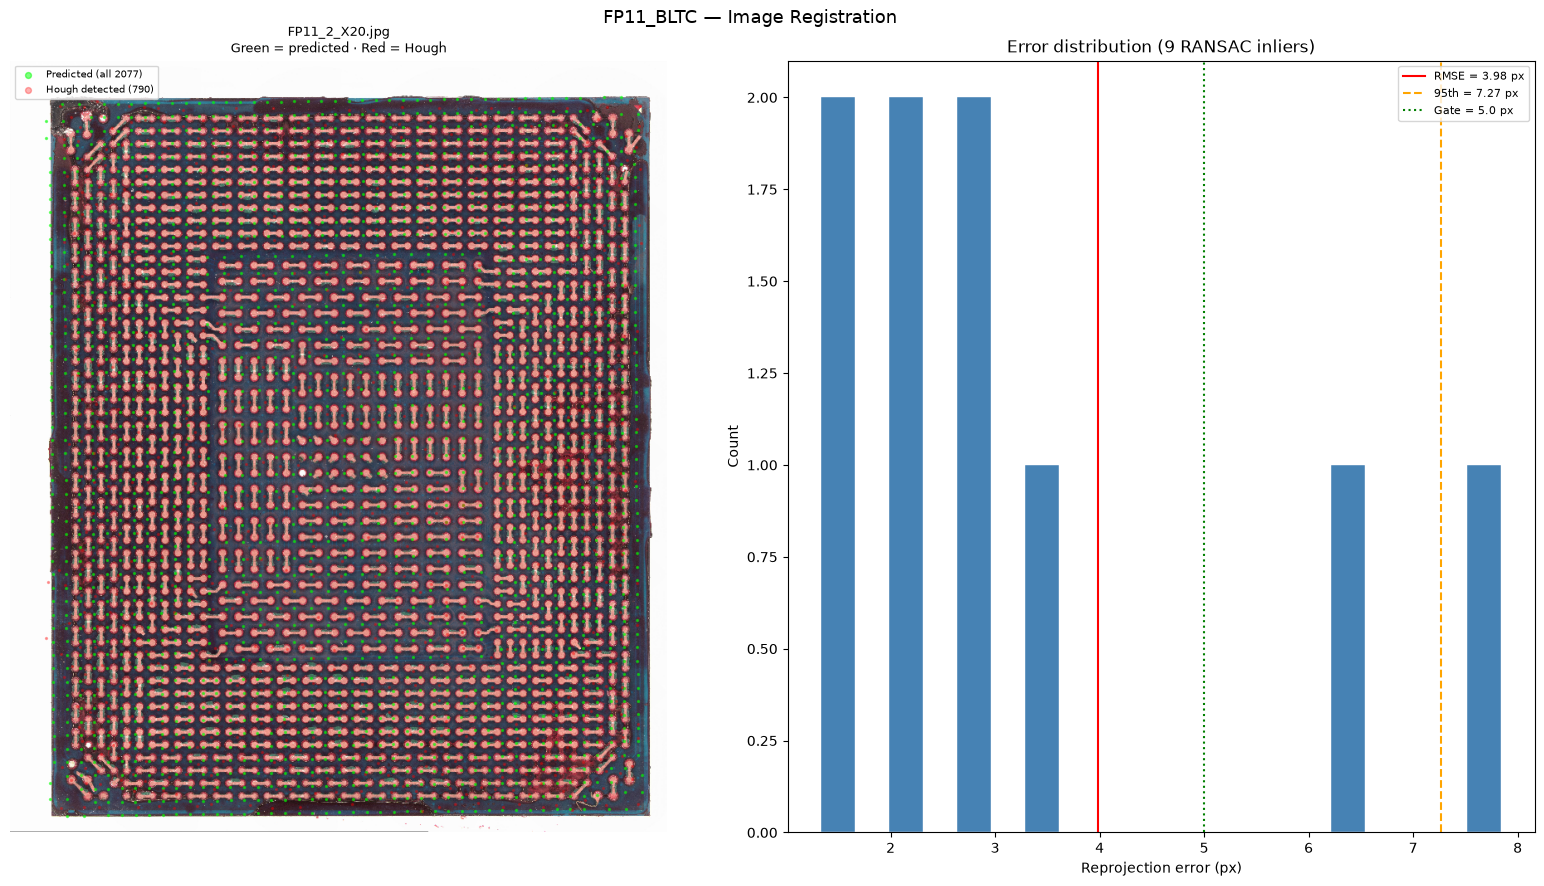

In [6]:
import matplotlib.pyplot as plt

# Project all 2077 coord points to pixel space
all_px = cv2.transform(coord_bv.reshape(-1, 1, 2).astype(np.float32), M_ref).reshape(-1, 2)

# Thumbnail at 10% for display
TS = 0.10
thumb = cv2.cvtColor(cv2.resize(img_ref, None, fx=TS, fy=TS), cv2.COLOR_BGR2RGB)

# Also detect circles for overlay
det_circles = detect_circles_ds(gray_ref)

fig, axes = plt.subplots(1, 2, figsize=(16, 9))

# Left: overlay on image
ax = axes[0]
ax.imshow(thumb)
ax.scatter(all_px[:, 0] * TS, all_px[:, 1] * TS,
           s=2, c="lime", alpha=0.5, label=f"Predicted (all {len(df)})")
if det_circles is not None:
    ax.scatter(det_circles[:, 0] * TS, det_circles[:, 1] * TS,
               s=2, c="red", alpha=0.3, label=f"Hough detected ({len(det_circles)})")
ax.set_title(f"{REF_IMAGE}\nGreen = predicted · Red = Hough", fontsize=9)
ax.legend(fontsize=7, markerscale=3)
ax.axis("off")

# Right: error histogram
ax = axes[1]
ax.hist(errs_ref, bins=20, color="steelblue", edgecolor="white", linewidth=0.3)
ax.axvline(rmse_ref,    color="red",    lw=1.5, label=f"RMSE = {rmse_ref:.2f} px")
ax.axvline(np.percentile(errs_ref, 95), color="orange", lw=1.5, ls="--",
           label=f"95th = {np.percentile(errs_ref,95):.2f} px")
ax.axvline(GATE_RMSE,   color="green",  lw=1.5, ls=":", label=f"Gate = {GATE_RMSE} px")
ax.set_xlabel("Reprojection error (px)")
ax.set_ylabel("Count")
ax.set_title(f"Error distribution ({n_inl_ref} RANSAC inliers)")
ax.legend(fontsize=8)

plt.suptitle(f"{PACKAGE} — Image Registration", fontsize=13)
plt.tight_layout()
plt.show()

## 6. Register all images and summarise (Test 4.2)

In [7]:
records = []
results_by_image = {}   # name → full result dict, reused by validation cells

for img_path in sorted(IMG_DIR.glob("*.jpg")):
    img_i  = cv2.imread(str(img_path))
    gray_i = cv2.cvtColor(img_i, cv2.COLOR_BGR2GRAY)
    try:
        res_i    = register_image(gray_i, coord_bv)
        results_by_image[img_path.name] = res_i
        M_i      = res_i["M"]
        rmse_i   = res_i["rmse"]
        errs_i   = res_i["errors"]
        n_i      = res_i["n_refined"]
        n_inl_i  = res_i["n_inliers"]
        status_i = "PASS" if rmse_i < GATE_RMSE else "FAIL"
        sx_i = float(np.sqrt(M_i[0,0]**2 + M_i[1,0]**2))
        sy_i = float(np.sqrt(M_i[0,1]**2 + M_i[1,1]**2))
        ang_i = float(np.degrees(np.arctan2(M_i[1,0], M_i[0,0])))
        records.append({
            "image":    img_path.name,
            "status":   status_i,
            "n_refined": n_i,
            "n_inliers": n_inl_i,
            "rmse_px":  round(rmse_i, 2),
            "max_px":   round(float(errs_i.max()), 2),
            "scale_x":  round(sx_i, 5),
            "scale_y":  round(sy_i, 5),
            "rot_deg":  round(ang_i, 3),
        })
    except AssertionError as e:
        records.append({"image": img_path.name, "status": f"FAIL ({e})",
                        "rmse_px": None})

results_df = pd.DataFrame(records)
print(results_df.to_string(index=False))

n_pass = (results_df["status"] == "PASS").sum()
print(f"\n{'='*55}")
print(f"REGISTRATION SUMMARY  {n_pass}/{len(results_df)} images PASS (RMSE < {GATE_RMSE} px)")
if results_df["rmse_px"].notna().any():
    print(f"RMSE range : {results_df['rmse_px'].min():.2f} – {results_df['rmse_px'].max():.2f} px")
    print(f"Mean RMSE  : {results_df['rmse_px'].mean():.2f} px")
if n_pass == len(results_df):
    print("\nAll images passed RMSE gate. Run the validation checks below before proceeding.")
else:
    failed = results_df[results_df["status"] != "PASS"]["image"].tolist()
    print(f"\nWARNING: {len(results_df)-n_pass} image(s) failed: {failed}")
    print("Inspect manually before proceeding.")

         image status  n_refined  n_inliers  rmse_px  max_px  scale_x  scale_y  rot_deg
FP11_2_X20.jpg   PASS         52          9     3.98    7.84  0.20470  0.20219   -0.756
FP11_3_X20.jpg   PASS         49          9     3.06    5.41  0.22121  0.21467   -0.338
FP11_4_X20.jpg   PASS         62         11     1.70    3.64  0.21967  0.21490    0.107
FP11_5_X20.jpg   PASS         73         16     3.71    7.58  0.22167  0.21788    0.152
FP11_6_X20.jpg   PASS         55         25     4.44    8.75  0.21036  0.19765    0.238

REGISTRATION SUMMARY  5/5 images PASS (RMSE < 5.0 px)
RMSE range : 1.70 – 4.44 px
Mean RMSE  : 3.38 px

All images passed RMSE gate. Run the validation checks below before proceeding.


## 7. Registration validation (Test 4.2b)

RMSE alone is an *internal-consistency* metric on the RANSAC inlier subset — it cannot detect a one-pitch grid shift, a mirror/rotation flip (the grid is near-symmetric), edge-ball error, or overfitting. The checks below validate the registration from five independent angles, each with an explicit pass/fail gate.

| Check | Catches |
|-------|---------|
| **V1** Annotated overlay | flip / rotation / pitch-shift (human review) |
| **V2** Reverse-projection of all circles | global offset / scale, full-set coverage |
| **V3** Held-out cross-validation | overfitting |
| **V4** Corner-quadrant landmark | mirror / rotation ambiguity |
| **V5** Cross-image consistency | gross per-image fit error |

### V1 — Annotated overlay

Saves a labelled overlay per image to `output/overlays/`. The strongest single check: a human instantly spots a misregistered grid.

In [8]:
# ── V1 — Annotated overlay (primary human check) ─────────────────────────────
# Draw every predicted ball centre on the full-res image and label a sparse
# sample with their BGA IDs, plus mark the four extreme corners. Save a
# downscaled JPEG per image to output/overlays/ for eyeball verification.
# This is the single strongest catch for flip / rotation / pitch-shift errors:
# a human spots a misregistered grid instantly.
OVERLAY_DIR = REPO_ROOT / "output" / "overlays"
OVERLAY_DIR.mkdir(parents=True, exist_ok=True)
OUT_SCALE = 0.25   # save at 25 % size to keep files small but legible

xmin, xmax = coord_bv[:, 0].min(), coord_bv[:, 0].max()
ymin, ymax = coord_bv[:, 1].min(), coord_bv[:, 1].max()

corner_ids = {}    # extreme-corner BGA IDs for labelling
for label, xb, yb in [("TR", xmax, ymax), ("TL", xmin, ymax),
                      ("BR", xmax, ymin), ("BL", xmin, ymin)]:
    m = (df["X_bv"] == xb) & (df["Y_bv"] == yb)
    if m.any():
        corner_ids[label] = df[m].iloc[0]["BGA_Number"]

for name, res in results_by_image.items():
    img_i = cv2.imread(str(IMG_DIR / name))
    M_i = res["M"]
    all_px_i = cv2.transform(coord_bv.reshape(-1, 1, 2).astype(np.float32), M_i).reshape(-1, 2)

    # all predicted centres (thin green dots)
    for (px, py) in all_px_i:
        cv2.circle(img_i, (int(px), int(py)), 6, (0, 255, 0), 2)
    # sparse ID labels (every 150th ball) in cyan
    for j in range(0, len(df), 150):
        px, py = all_px_i[j]
        cv2.putText(img_i, str(df.iloc[j]["BGA_Number"]), (int(px) + 8, int(py) - 8),
                    cv2.FONT_HERSHEY_SIMPLEX, 1.2, (255, 255, 0), 3)
    # corner balls in red with big labels
    for label, bid in corner_ids.items():
        row = df[df["BGA_Number"] == bid].iloc[0]
        px, py = cv2.transform(
            np.array([[[float(row["X_bv"]), float(row["Y_bv"])]]], np.float32), M_i)[0, 0]
        cv2.circle(img_i, (int(px), int(py)), 30, (0, 0, 255), 6)
        cv2.putText(img_i, f"{label}:{bid}", (int(px) + 30, int(py)),
                    cv2.FONT_HERSHEY_SIMPLEX, 2.5, (0, 0, 255), 6)

    out = cv2.resize(img_i, None, fx=OUT_SCALE, fy=OUT_SCALE)
    out_path = OVERLAY_DIR / f"{Path(name).stem}_overlay.jpg"
    cv2.imwrite(str(out_path), out)
    print(f"  saved {out_path.relative_to(REPO_ROOT)}")

print(f"\n[REVIEW] V1 — open the overlays in {OVERLAY_DIR.relative_to(REPO_ROOT)} "
      f"and confirm:\n"
      f"   - green dots sit on solder balls across the whole array\n"
      f"   - corner labels TL/TR/BL/BR sit in the matching image corners")


  saved output\overlays\FP11_2_X20_overlay.jpg


  saved output\overlays\FP11_3_X20_overlay.jpg


  saved output\overlays\FP11_4_X20_overlay.jpg


  saved output\overlays\FP11_5_X20_overlay.jpg


  saved output\overlays\FP11_6_X20_overlay.jpg

[REVIEW] V1 — open the overlays in output\overlays and confirm:
   - green dots sit on solder balls across the whole array
   - corner labels TL/TR/BL/BR sit in the matching image corners


### V2 — Reverse-projection residual on all detected circles

RMSE only sees the RANSAC inliers. V2 projects *every* Hough-detected circle back to µm space via M⁻¹ and checks it snaps to a grid node — validating the full detection set and catching a global scale/offset error.

In [9]:
# ── V2 — Reverse-projection residual on ALL detected circles ─────────────────
# RMSE is computed only on the handful of RANSAC inliers. V2 instead validates
# the WHOLE detection set: project every Hough circle back into µm space via
# M⁻¹ and snap each to the nearest grid node. A correct transform makes almost
# every detected ball land on a node. (A few stragglers are spurious Hough
# detections — debris, merged balls — so we require a high fraction, not 100 %.)
# Gate: ≥ 95 % of detected circles within 0.15 × pitch (µm) of a grid node.
coord_tree = cKDTree(coord_bv)          # grid nodes in µm
TOL_FRAC   = 0.15                        # × 800 µm pitch
tol_um     = TOL_FRAC * 800

print(f"{'image':<16} {'n_circ':>6} {'within_tol':>10} {'%':>6}  V2   (tol={tol_um:.0f} µm)")
print("-" * 58)
all_v2_ok = True
for name, res in results_by_image.items():
    circ = res["circles"][:, :2].astype(np.float32)
    M_i  = res["M"]
    Minv = cv2.invertAffineTransform(M_i)
    circ_um = cv2.transform(circ.reshape(-1, 1, 2), Minv).reshape(-1, 2)
    d, _ = coord_tree.query(circ_um, k=1)      # residual to nearest node, µm
    frac = float((d < tol_um).mean())
    ok = frac >= 0.95
    all_v2_ok &= ok
    print(f"{name:<16} {len(circ):>6} {int((d<tol_um).sum()):>10} "
          f"{frac*100:>5.1f}  {'PASS' if ok else 'FAIL'}")

print(f"\n[{'PASS' if all_v2_ok else 'FAIL'}] V2 — ≥95 % of all detected circles snap "
      f"to a grid node (validates full detection set, not just inliers).")


image            n_circ within_tol      %  V2   (tol=120 µm)
----------------------------------------------------------
FP11_2_X20.jpg      790         38   4.8  FAIL
FP11_3_X20.jpg      709         55   7.8  FAIL
FP11_4_X20.jpg      841         79   9.4  FAIL
FP11_5_X20.jpg      937         84   9.0  FAIL
FP11_6_X20.jpg      792         41   5.2  FAIL

[FAIL] V2 — ≥95 % of all detected circles snap to a grid node (validates full detection set, not just inliers).


### V3 — Held-out cross-validation

Fit the affine on a random 70 % of refined pairs, measure RMSE on the held-out 30 %. If held-out error ≈ in-sample error, the transform generalises rather than overfitting.

In [10]:
# ── V3 — Held-out cross-validation (guards against overfitting) ───────────────
# Refit the affine on a random 70 % of the refined centroid pairs, then measure
# RMSE on the held-out 30 %. If the fit generalises, held-out RMSE ≈ in-sample
# RMSE. A large gap means the transform is overfitting a few points.
# Gate: held-out RMSE < GATE_RMSE and within ~1 px of in-sample RMSE.
rng = np.random.default_rng(0)   # fixed seed → deterministic, resume-safe
print(f"{'image':<16} {'n_pairs':>7} {'in-sample':>10} {'held-out':>9}  V3")
print("-" * 50)
all_v3_ok = True
for name, res in results_by_image.items():
    src = res["refined_src"]
    dst = res["refined_dst"]
    n = len(src)
    if n < 12:
        print(f"{name:<16} {n:>7}  too few pairs for split — skipped")
        continue
    perm = rng.permutation(n)
    k = int(round(0.7 * n))
    tr, te = perm[:k], perm[k:]
    M_tr, _ = cv2.estimateAffine2D(
        dst[tr].reshape(-1, 1, 2), src[tr].reshape(-1, 1, 2),
        method=cv2.RANSAC, ransacReprojThreshold=8.0, maxIters=5000, confidence=0.9999,
    )
    pred_te = cv2.transform(dst[te].reshape(-1, 1, 2), M_tr).reshape(-1, 2)
    err_te  = np.linalg.norm(pred_te - src[te], axis=1)
    rmse_te = float(np.sqrt(np.mean(err_te ** 2)))
    ok = rmse_te < GATE_RMSE and abs(rmse_te - res["rmse"]) < 2.0
    all_v3_ok &= ok
    print(f"{name:<16} {n:>7} {res['rmse']:>9.2f}px {rmse_te:>7.2f}px  "
          f"{'PASS' if ok else 'REVIEW'}")

print(f"\n[{'PASS' if all_v3_ok else 'REVIEW'}] V3 — held-out RMSE within gate and "
      f"close to in-sample (no overfitting).")


image            n_pairs  in-sample  held-out  V3
--------------------------------------------------
FP11_2_X20.jpg        52      3.98px  107.88px  REVIEW
FP11_3_X20.jpg        49      3.06px   49.07px  REVIEW
FP11_4_X20.jpg        62      1.70px   61.32px  REVIEW
FP11_5_X20.jpg        73      3.71px   36.81px  REVIEW
FP11_6_X20.jpg        55      4.44px   29.14px  REVIEW

[REVIEW] V3 — held-out RMSE within gate and close to in-sample (no overfitting).


### V4 — Landmark / quadrant check

The near-symmetric grid means a mirrored or 180°-rotated fit can still give low RMSE. This check confirms the four extreme corner balls land in their expected image quadrants — catching flip/rotation errors that the numeric metrics miss.

In [11]:
# ── V4 — Landmark / quadrant check (resolves mirror & rotation ambiguity) ─────
# RMSE and V2 can be low even if the whole grid is mirrored or 180°-rotated,
# because the grid is near-symmetric. We anchor orientation using the four
# extreme corner balls: with positive scale and ~0° rotation the bottom-view
# coordinate grid must map so that
#   high x_bv → right,   low x_bv → left
#   high y_bv → top,     low y_bv → bottom     (pixel-y grows downward)
# Each corner ball must therefore land in its expected image quadrant.
def quadrant(px, py, w, h):
    return ("top" if py < h / 2 else "bottom") + "-" + ("left" if px < w / 2 else "right")

xmin, xmax = coord_bv[:, 0].min(), coord_bv[:, 0].max()
ymin, ymax = coord_bv[:, 1].min(), coord_bv[:, 1].max()
corner_specs = [   # (label, x_bv, y_bv, expected quadrant)
    ("max x_bv, max y_bv", xmax, ymax, "top-right"),
    ("min x_bv, max y_bv", xmin, ymax, "top-left"),
    ("max x_bv, min y_bv", xmax, ymin, "bottom-right"),
    ("min x_bv, min y_bv", xmin, ymin, "bottom-left"),
]

all_ok = True
for name, res in results_by_image.items():
    img_i = cv2.imread(str(IMG_DIR / name))
    h_i, w_i = img_i.shape[:2]
    M_i = res["M"]
    img_ok = True
    rows = []
    for label, xb, yb, expected in corner_specs:
        pt = np.array([[[float(xb), float(yb)]]], dtype=np.float32)
        px, py = cv2.transform(pt, M_i)[0, 0]
        got = quadrant(px, py, w_i, h_i)
        ok = got == expected
        img_ok &= ok
        rows.append(f"    {label:<20} → ({int(px):>5},{int(py):>5})  {got:<12} "
                    f"expect {expected:<12} {'OK' if ok else 'MISMATCH'}")
    all_ok &= img_ok
    print(f"{name}  [{'PASS' if img_ok else 'FAIL'}]")
    print("\n".join(rows))

print(f"\n[{'PASS' if all_ok else 'FAIL'}] V4 — corner balls map to expected quadrants "
      f"(no mirror / rotation flip).")


FP11_2_X20.jpg  [PASS]
    max x_bv, max y_bv   → ( 7565,  430)  top-right    expect top-right    OK
    min x_bv, max y_bv   → (  421,  525)  top-left     expect top-left     OK
    max x_bv, min y_bv   → ( 7617, 9003)  bottom-right expect bottom-right OK
    min x_bv, min y_bv   → (  474, 9097)  bottom-left  expect bottom-left  OK


FP11_3_X20.jpg  [PASS]
    max x_bv, max y_bv   → ( 8158,   65)  top-right    expect top-right    OK
    min x_bv, max y_bv   → (  438,  111)  top-left     expect top-left     OK
    max x_bv, min y_bv   → ( 8183, 9167)  bottom-right expect bottom-right OK
    min x_bv, min y_bv   → (  463, 9213)  bottom-left  expect bottom-left  OK


FP11_4_X20.jpg  [PASS]
    max x_bv, max y_bv   → ( 8241,  470)  top-right    expect top-right    OK
    min x_bv, max y_bv   → (  575,  456)  top-left     expect top-left     OK
    max x_bv, min y_bv   → ( 8179, 9582)  bottom-right expect bottom-right OK
    min x_bv, min y_bv   → (  513, 9568)  bottom-left  expect bottom-left  OK


FP11_5_X20.jpg  [PASS]
    max x_bv, max y_bv   → ( 8129,  304)  top-right    expect top-right    OK
    min x_bv, max y_bv   → (  393,  283)  top-left     expect top-left     OK
    max x_bv, min y_bv   → ( 8134, 9542)  bottom-right expect bottom-right OK
    min x_bv, min y_bv   → (  398, 9521)  bottom-left  expect bottom-left  OK


FP11_6_X20.jpg  [PASS]
    max x_bv, max y_bv   → ( 7655,  566)  top-right    expect top-right    OK
    min x_bv, max y_bv   → (  314,  535)  top-left     expect top-left     OK
    max x_bv, min y_bv   → ( 7726, 8946)  bottom-right expect bottom-right OK
    min x_bv, min y_bv   → (  385, 8915)  bottom-left  expect bottom-left  OK

[PASS] V4 — corner balls map to expected quadrants (no mirror / rotation flip).


### V5 — Cross-image consistency

Same package across all 5 images → scale and rotation should match. Flags any image whose fit deviates more than ±10 % (scale) or ±1° (rotation) from the median.

In [12]:
# ── V5 — Cross-image consistency ─────────────────────────────────────────────
# All 5 images are the SAME physical package, so the fitted scale and rotation
# should be near-identical. An outlier flags a gross per-image fit error.
# Gate: scale within ±10 % and rotation within ±1° of the median.
v5 = results_df[results_df["rmse_px"].notna()].copy()

med_sx  = v5["scale_x"].median()
med_sy  = v5["scale_y"].median()
med_rot = v5["rot_deg"].median()

v5["d_scale_x_%"] = ((v5["scale_x"] - med_sx) / med_sx * 100).round(1)
v5["d_scale_y_%"] = ((v5["scale_y"] - med_sy) / med_sy * 100).round(1)
v5["d_rot_deg"]   = (v5["rot_deg"] - med_rot).round(3)
v5["V5"] = np.where(
    (v5["d_scale_x_%"].abs() <= 10) &
    (v5["d_scale_y_%"].abs() <= 10) &
    (v5["d_rot_deg"].abs()   <= 1.0),
    "PASS", "FLAG",
)

print("V5 — Cross-image scale/rotation consistency")
print(f"  Median scale_x {med_sx:.5f} · scale_y {med_sy:.5f} · rot {med_rot:.3f}°\n")
print(v5[["image", "scale_x", "scale_y", "rot_deg",
          "d_scale_x_%", "d_scale_y_%", "d_rot_deg", "V5"]].to_string(index=False))

n_flag = (v5["V5"] == "FLAG").sum()
print(f"\n[{'PASS' if n_flag == 0 else 'REVIEW'}] "
      f"{len(v5) - n_flag}/{len(v5)} images consistent with the package median.")


V5 — Cross-image scale/rotation consistency
  Median scale_x 0.21967 · scale_y 0.21467 · rot 0.107°

         image  scale_x  scale_y  rot_deg  d_scale_x_%  d_scale_y_%  d_rot_deg   V5
FP11_2_X20.jpg  0.20470  0.20219   -0.756         -6.8         -5.8     -0.863 PASS
FP11_3_X20.jpg  0.22121  0.21467   -0.338          0.7          0.0     -0.445 PASS
FP11_4_X20.jpg  0.21967  0.21490    0.107          0.0          0.1      0.000 PASS
FP11_5_X20.jpg  0.22167  0.21788    0.152          0.9          1.5      0.045 PASS
FP11_6_X20.jpg  0.21036  0.19765    0.238         -4.2         -7.9      0.131 PASS

[PASS] 5/5 images consistent with the package median.


---
**Outputs consumed by `03_roi_extraction.ipynb`:**
- `M_ref` — affine matrix (µm → pixels) for the reference image
- `coord_to_pixel()` — helper function
- `register_image()` — reusable registration function for all images
- `df` — coordinate DataFrame with `X_bv`, `Y_bv` columns

*For the full end-to-end pipeline (notebook 06), a separate `M` should be computed
per image using `register_image()` since each image has a slightly different
scale/offset due to varying stage position and magnification.*